In [ ]:
import pandas as pd

In [ ]:
df_iris=pd.read_csv("Iris.csv")

In [ ]:
df_iris.shape

(150, 6)

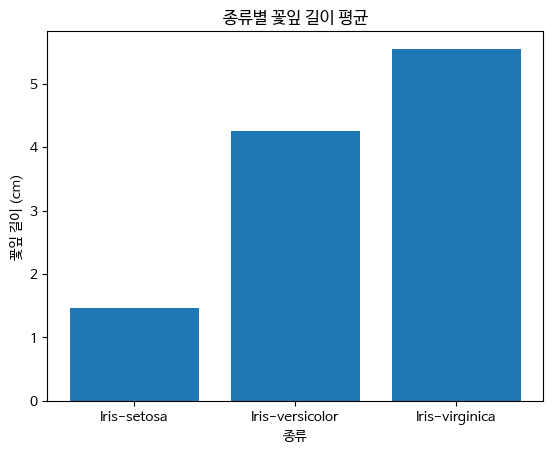

In [ ]:
import matplotlib.pyplot as plt
plt.rc('font', family="NanumBarunGothic")
petal_mean = df_iris.groupby('Species')['PetalLengthCm'].mean()
plt.bar(petal_mean.index, petal_mean.values)
plt.xlabel('종류')
plt.title('종류별 꽃잎 길이 평균')
plt.ylabel('꽃잎 길이 (cm)')
plt.show()

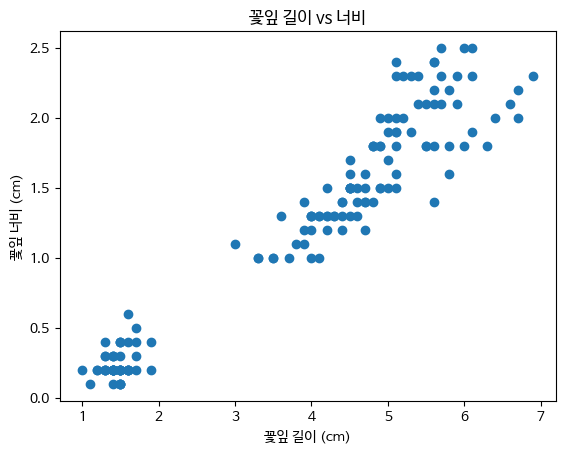

In [ ]:
plt.scatter(df_iris['PetalLengthCm'], df_iris['PetalWidthCm'])
plt.title('꽃잎 길이 vs 너비')
plt.xlabel('꽃잎 길이 (cm)')
plt.ylabel('꽃잎 너비 (cm)')
plt.show()

문제1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
#문제1 iris.csv 파일 df에 저장
df = pd.read_csv('Iris.csv')

In [29]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
#문제1 상위 5행 확인
df.head(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
#문제1 행열 개수 확인, 150행 6열
df.shape

(150, 6)

In [8]:
#문제1 자료형과 결측치 확인-info로 원큐에 체크-누락된 값 없고 정수1 실수4 문자열1
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [9]:
#문제1 수치형 컬럼 기초통계량-디스크리브 사용
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [13]:
#문제2 각 열(칼럼)별 결측치 개수 확인-isna에 sum 하나만 붙이면 열별 결측치 나옴
df.isna().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [17]:
#문제2 품종 종류와 품종별 행 개수 확인하기-[열지정].벨류카운트로 한번에 확인
df["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [30]:
#문제3 불필요한 열 제거(ID 칼럼)-원본 자체에서 Id 열을 제거-df로 덮어쓰기
df = df.drop(columns=['Id'])

In [35]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [36]:
#문제4 특성과 레이블 분리
print(df.keys())

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [43]:
# X: Species를 제외한 나머지 4개 컬럼-특성 레이블
X = df.drop('Species', axis=1)
# y: 정답 레이블
y = df['Species']

In [52]:
print(X.shape,'\n',y.shape)

(150, 4) 
 (150,)


In [55]:
#문제5 학습용 데이터, 테스트용 데이터 분리(데이터전처리 과정)-8:2
#from df import train_test_split-하다가 안되서 AI 돌려보니 판다스는 데이터 처리 역할이고 머신러닝은 sklearn으로 한다함
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [59]:
#문제6 KNN 분류 모델로 모델 만들고 학습시키기
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [61]:
#문제7 예측하기
y_pred = knn.predict(X_test)
print('테스트 세트 예측 값:\n',y_pred)
print('테스트 세트 실제 타킷:\n', y_test)

테스트 세트 예측 값:
 ['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']
테스트 세트 실제 타킷:
 38         Iris-setosa
127     Iris-virginica
57     Iris-versicolor
93     Iris-versicolor
42         Iris-setosa
56     Iris-versicolor
22         Iris-setosa
20         Iris-setosa
147     Iris-virginica
84     Iris-versicolor
107     Iris-virginica
141     Iris-virginica
104     Iris-virginica
51     Iris-versicolor
7          Iris-setosa
49         Iris-setosa
14         Iris-setosa
69     Iris-versicolor
63     Iris-versicolor
138     Iris-virginica
10         I

In [63]:
#문제8 완성된 분류모델 평가하기-정확도 평가고 1에 가까울수록 훈련이 잘된거
print(f'훈련 세트 정확도: {knn.score(X_train, y_train):.3f}')  #.3f는 소수점 3자리까지만 출력되게 제한한 것.
print(f'테스트 세트 정확도: {knn.score(X_test, y_test):.3f}')  #꼭 f포맷팅으로 할 필요 없으나 f포맷팅이 편함

훈련 세트 정확도: 0.958
테스트 세트 정확도: 1.000
